# Lista 01 de Visão Computacional
Beatriz Rodrigues Cavalcante - 22210505

Hugo Coêlho da Silva - 22111533

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [4]:
def show_images(*images: np.ndarray, titles: list[str] | None = None, columns: int = 2, scale: int = 5) -> None:
    num_images = len(images)
    
    if titles is None:
        titles = [f'Image {i+1}' for i in range(num_images)]
    
    rows = (num_images + columns - 1) // columns 

    fig, axes = plt.subplots(rows, columns, figsize=(scale * columns, scale * rows))
    axes = np.array(axes).reshape(rows, columns)

    for ax, img, title in zip(axes.flat, images, titles):
        ax.imshow(img, cmap='gray')
        ax.set_title(title)

    for i in range(num_images, rows * columns):
        fig.delaxes(axes.flat[i])

    plt.tight_layout()

def show_image(image: np.ndarray, title: str = None, dpi: int = 100) -> None:
    height, width, _ = image.shape
    
    figsize = (width / dpi, height / dpi)
    
    plt.figure(figsize=figsize, dpi=dpi)
    plt.imshow(image, cmap='gray' if len(image.shape) == 2 else None)
    plt.title(title if title else "")

    plt.tight_layout()

## Questão 1
Questão que implementa uma função de leitura e salvamento de imagens .ppm, e uma função de aplicação de um filtro de blur com convolução.

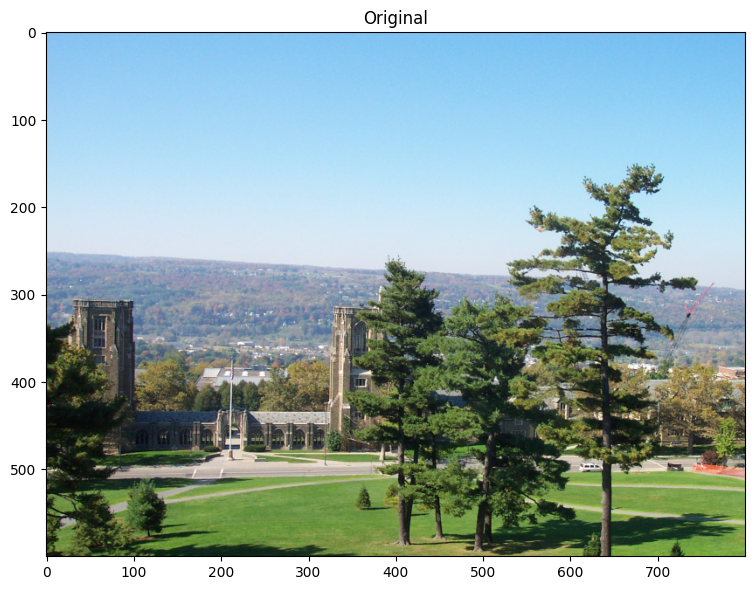

In [ ]:
def read_ppm(file_path: str):
    try:
        with open(file_path, 'rb') as f:
            ppm_type = f.readline().strip()
            if ppm_type not in [b'P6']:
                raise ValueError("Invalid PPM format. Only P6 are supported.")

            def token_stream():
                for line in f:
                    line = line.split(b"#", 1)[0].strip()
                    if not line:
                        continue
                    for token in line.split():
                        yield token

            tokens = token_stream()
            width = int(next(tokens))
            height = int(next(tokens))
            max_val = int(next(tokens))
            
            data = np.frombuffer(f.read(), dtype=np.uint8).reshape((height, width, 3))
           
            return {
                "type": ppm_type.decode(),
                "width": width,
                "height": height,
                "max_val": max_val,
                "pixels": data,
            }
    except FileNotFoundError:
        print(f'Error: file {file_path} not found.')

def save_ppm(ppm_image, filename: str, foldername:str='./output'):
    folder = Path(foldername)
    folder.mkdir(exist_ok=True, parents=True)
    filepath = folder / Path(filename)

    pixels = np.clip(ppm_image["pixels"], 0, 255).astype(np.uint8)

    with open(filepath, 'wb') as ppm:
        ppm.write(f"{ppm_image["type"]}\n".encode('ascii'))
        ppm.write(f"{ppm_image["width"]} {ppm_image["height"]}\n".encode('ascii'))
        ppm.write(f"{ppm_image["max_val"]}\n".encode('ascii'))
        ppm.write(pixels.tobytes())


img_path = '../ppm_images/cayuga_1.ppm'
img = read_ppm(img_path)
if img is not None:
    show_image(img["pixels"], title="Original")
    save_ppm(img, 'teste1.ppm')